In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [5]:
df = pd.read_csv("onlinefraud.csv")   # Replace with your CSV filename

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
print(df.shape)

print(df.columns)

df.info()

(6362620, 11)
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [8]:
df.drop(["nameOrig","nameDest"],axis=1,inplace=True)

In [9]:
encoder = LabelEncoder()

df["type"] = encoder.fit_transform(df["type"])

In [10]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0


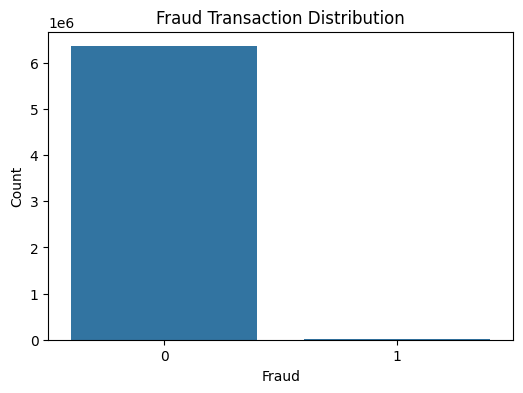

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="isFraud",data=df)

plt.title("Fraud Transaction Distribution")

plt.xlabel("Fraud")

plt.ylabel("Count")

plt.show()

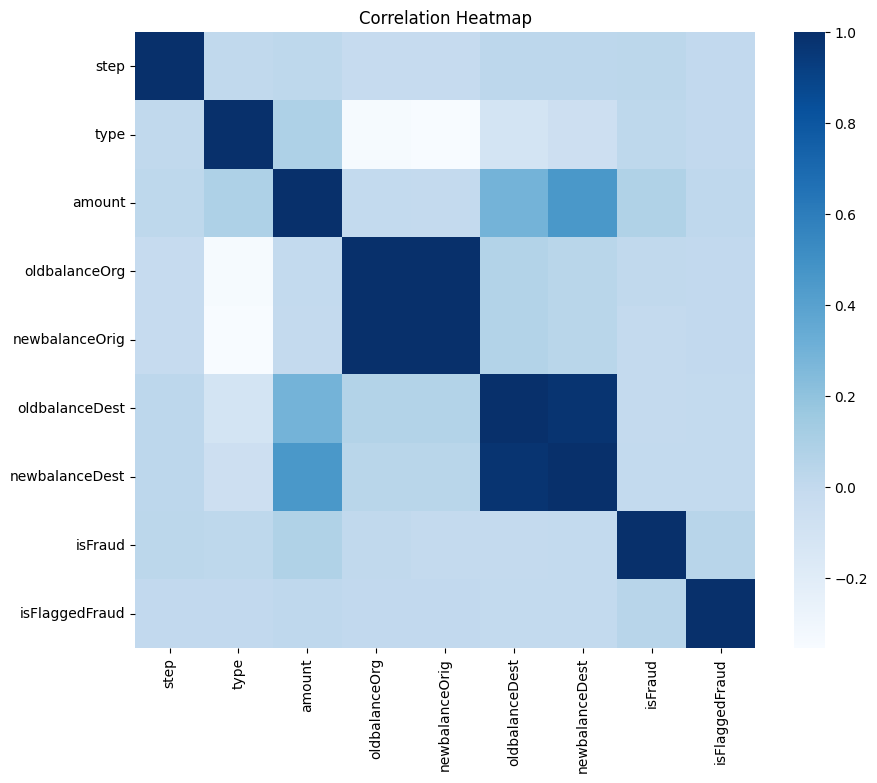

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

In [13]:
X = df.drop("isFraud",axis=1)

y = df["isFraud"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42

)

In [15]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [16]:
prediction = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test,prediction)

print("Accuracy =",accuracy)

Accuracy = 0.9990947125555196


In [19]:
cm = confusion_matrix(y_test,prediction)

print(cm)

[[1270723     181]
 [    971     649]]


In [17]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.78      0.40      0.53      1620

    accuracy                           1.00   1272524
   macro avg       0.89      0.70      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524



In [20]:
result = pd.DataFrame({

"Actual":y_test,

"Predicted":prediction

})

result.head(20)

,Actual,Predicted
3737323,0,0
264914,0,0
85647,0,0
5899326,0,0
2544263,0,0
3494160,0,0
2331654,0,0
1414955,0,0
2938135,0,0
6133806,0,0


In [22]:
sample = [[1, 2, 5000, 10000, 5000, 0, 5000, 0]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction")
else:
    print("Genuine Transaction")

Genuine Transaction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
